#  Cluster Variable Generation 

In [136]:
 # import necessary all library
import time
start = time.time()
import geopandas as gpd
import pandas as pd
from functools import reduce
import sys
'geopandas' in sys.modules
#!pip3 install matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import io
import pandas as pd
import networkx as nx
import osmnx as ox
import os 
from geopandas import GeoDataFrame, read_file
from geopandas.tools import overlay
import shapely.geometry as geom
import shapely.wkt

In [137]:
# Helper Function
def min_distance_ppoly(point, polygon):
    return polygon.distance(point).min()

In [138]:
#!pip install contextily

In [139]:
import warnings
warnings.filterwarnings("ignore")

# Input your buffer size here in meter unit

In [140]:
# Input your buffer size here in meter unit
# 0.1 mile=160.934m
#0.25 mile=402.336 m
#0.5 mile=804.672,
#1 mile=1609.34,
#1.5 mile=2414.02,
#2 mile=3218.69

#buffer size in meter
size=402.336 

In [141]:
# read the eco counter data
eco_counter=pd.read_csv(r'C:\Undergraduate Research\cleaned_qualified_count_data_2022.csv')
eco_counter=eco_counter.drop_duplicates(subset=['site_name','latitude','longitude','stratum'])
eco_counter=eco_counter[['site_name','latitude','longitude','stratum']]
eco_counter.head()

,site_name,latitude,longitude,stratum
0,(01) 11th St. Between Howard & Folsom,37.772475,-122.414678,Path
8759,(02) 17th St. between Mission & Valencia,37.763376,-122.420433,Bike Route
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,37.759250,-122.463770,Path
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,37.761326,-122.464070,Path
35036,(10) 8th St. Between Folsom & Harrison,37.774740,-122.409820,Bike Route


In [142]:
eco_counter.shape

(51, 4)

In [143]:
# lets convert the dataframes crs system
eco_counter1 = gpd.GeoDataFrame(eco_counter, geometry=gpd.points_from_xy(eco_counter.longitude, eco_counter.latitude))
eco_counter2 = eco_counter1.set_crs("EPSG:4326")
eco_counter2_proj = eco_counter2.to_crs(epsg=32610)
eco_counter2_proj.head()
#eco_counter2

,site_name,latitude,longitude,stratum,geometry
0,(01) 11th St. Between Howard & Folsom,37.772475,-122.414678,Path,POINT (551548.301 4180732.421)
8759,(02) 17th St. between Mission & Valencia,37.763376,-122.420433,Bike Route,POINT (551047.718 4179719.739)
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,37.759250,-122.463770,Path,POINT (547233.230 4179239.202)
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,37.761326,-122.464070,Path,POINT (547205.485 4179469.380)
35036,(10) 8th St. Between Folsom & Harrison,37.774740,-122.409820,Bike Route,POINT (551974.554 4180986.410)


In [144]:
gdf1 = eco_counter2_proj.copy()
gdf1['geometry'] = gdf1['geometry'].buffer(size)
gdf1.head()

,site_name,latitude,longitude,stratum,geometry
0,(01) 11th St. Between Howard & Folsom,37.772475,-122.414678,Path,"POLYGON ((551950.637 4180732.421, 551948.699 4..."
8759,(02) 17th St. between Mission & Valencia,37.763376,-122.420433,Bike Route,"POLYGON ((551450.054 4179719.739, 551448.116 4..."
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,37.759250,-122.463770,Path,"POLYGON ((547635.566 4179239.202, 547633.629 4..."
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,37.761326,-122.464070,Path,"POLYGON ((547607.821 4179469.380, 547605.884 4..."
35036,(10) 8th St. Between Folsom & Harrison,37.774740,-122.409820,Bike Route,"POLYGON ((552376.890 4180986.410, 552374.953 4..."


In [145]:
# import contextily as ctx
# gdfm = gdf1.to_crs(epsg=3857) # This EPSG-3857 just for ploting
# ax = gdfm.plot(figsize=(20, 20), alpha=0.5, edgecolor='k')
# ctx.add_basemap(ax)

# Now calculate the land use variables within the buffer

In [146]:
## Try to pull whole CA state Network using polygon
ca_poly=gpd.read_file(r'C:\Undergraduate Research\ca_state\CA_State.shp',encoding='utf-8')
ca_poly2=gpd.GeoDataFrame(ca_poly, geometry='geometry', crs='EPSG:3857')
one_mile=1609.34
ca_poly2['geometry'] = ca_poly2['geometry'].buffer(one_mile)
ca_poly3=ca_poly2.to_crs("epsg:4326")
ca_poly3

,OBJECTID,REGION,DIVISION,STATEFP,STATENS,GEOID,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Le_1,Shape_Area,geometry
0,56,4,9,06,01779778,06,CA,California,00,G4000,A,4.034672e+11,2.049980e+10,+37.1551773,-119.5434183,5.258041e+06,5.258041e+06,6.718927e+11,"MULTIPOLYGON (((-124.44237 40.35934, -124.4430..."


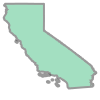

In [147]:
# lets use buffer only to extract the land use
polygon=ca_poly3.loc[0,'geometry']
polygon

In [148]:
gdf1.crs

<Derived Projected CRS: EPSG:32610>
Name: WGS 84 / UTM zone 10N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 126°W and 120°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - British Columbia (BC); Northwest Territories (NWT); Nunavut; Yukon. United States (USA) - Alaska (AK).
- bounds: (-126.0, 0.0, -120.0, 84.0)
Coordinate Operation:
- name: UTM zone 10N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [149]:
#!chcp 1252
!chcp 65001

Active code page: 65001


In [150]:
#tags = {'landuse': 'grass'}
#industrial = ox.geometries_from_polygon(polygon, tags)
#industrial.head()

In [151]:
#https://wiki.openstreetmap.org/wiki/Key:landuse
tags = {'landuse': ['grass','commercial','industrial','residential','retail','institutional','forest','education']}
landuse = ox.geometries_from_polygon(polygon, tags)
landuse.head()

barrier                     geometry highway railway  \
element_type osmid                                                             
node         368174331      NaN  POINT (-116.95975 32.85949)     NaN     NaN   
             596183787      NaN  POINT (-117.24583 32.74844)     NaN     NaN   
             596740133      NaN  POINT (-117.15252 32.71013)     NaN     NaN   
             596796626      NaN  POINT (-117.22827 32.73877)     NaN     NaN   
             2329997897     NaN  POINT (-117.22639 32.86046)     NaN     NaN   

                                                                    source  \
element_type osmid                                                           
node         368174331                                       USGS Geonames   
             596183787   SanGIS Addresses Public Domain (http://www.san...   
             596740133   SanGIS Addresses Public Domain (http://www.san...   
             596796626   SanGIS Addresses Public Domain (http://www.san...   
             2329997897                                               Bing   

                        addr:state  ele gnis:feature_id      landuse  \
element_type osmid                                                     
node         368174331          CA  118          243594  residential   
             596183787         NaN  NaN             NaN  residential   
             596740133          CA  NaN             NaN  residential   
             596796626         NaN  NaN             NaN  residential   
             2329997897        NaN  NaN             NaN  residential   

                                           name  ... landuse:historic  \
element_type osmid                               ...                    
node         368174331   Home for Guiding Hands  ...              NaN   
             596183787                      NaN  ...              NaN   
             596740133                  Entrada  ...              NaN   
             596796626                      NaN  ...              NaN   
             2329997897                  Madrid  ...              NaN   

                        recycling:electrical_appliances max_age pedagogy  \
element_type osmid                                                         
node         368174331                              NaN     NaN      NaN   
             596183787                              NaN     NaN      NaN   
             596740133                              NaN     NaN      NaN   
             596796626                              NaN     NaN      NaN   
             2329997897                             NaN     NaN      NaN   

                        school:gender school:language iucn_level protected  \
element_type osmid                                                           
node         368174331            NaN             NaN        NaN       NaN   
             596183787            NaN             NaN        NaN       NaN   
             596740133            NaN             NaN        NaN       NaN   
             596796626            NaN             NaN        NaN       NaN   
             2329997897           NaN             NaN        NaN       NaN   

                        protection_object site_ownership  
element_type osmid                                        
node         368174331                NaN            NaN  
             596183787                NaN            NaN  
             596740133                NaN            NaN  
             596796626                NaN            NaN  
             2329997897               NaN            NaN  

[5 rows x 883 columns]

In [152]:
landuse['landuse'].unique()

array(['residential', 'industrial', 'retail', 'commercial', 'forest',
       'grass', 'education', 'institutional'], dtype=object)

In [153]:
# Avoid this error- TopologyException: Input geom 0 is invalid: Self-intersection at 2307899.6553931381 208383.49467431975. Do the followings
landuse["geometry"]=landuse.geometry.buffer(0)
landuse = landuse.reset_index(level=0)
landuse = landuse.reset_index(level=0)
landuse.head(2)

,osmid,element_type,barrier,geometry,highway,railway,source,addr:state,ele,gnis:feature_id,...,landuse:historic,recycling:electrical_appliances,max_age,pedagogy,school:gender,school:language,iucn_level,protected,protection_object,site_ownership
0,368174331,node,NaN,POLYGON EMPTY,NaN,NaN,USGS Geonames,CA,118,243594,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,596183787,node,NaN,POLYGON EMPTY,NaN,NaN,SanGIS Addresses Public Domain (http://www.san...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [154]:
landuse1=landuse[['osmid','geometry','landuse']]
landuse2=gpd.GeoDataFrame(landuse1, geometry='geometry', crs={'init': 'epsg:4326'})
luse_proj = landuse2.to_crs(epsg=32610)
luse_proj.head()

C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\pyproj\crs\crs.py:130: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


,osmid,geometry,landuse
0,368174331,POLYGON EMPTY,residential
1,596183787,POLYGON EMPTY,residential
2,596740133,POLYGON EMPTY,residential
3,596796626,POLYGON EMPTY,residential
4,2329997897,POLYGON EMPTY,residential


In [155]:
# Clip the data using GeoPandas clip
buffer_clip = gpd.clip(luse_proj, gdf1)
buffer_clip.head(5)

,osmid,geometry,landuse
5698,1444414753,"POLYGON ((1060813.032 3641199.453, 1060829.789...",retail
5699,1444415267,"POLYGON ((1060508.105 3640989.529, 1060473.743...",retail
635,276160288,"POLYGON ((1060099.022 3641182.619, 1060410.143...",retail
218,109937201,"POLYGON ((1060457.614 3641204.713, 1060793.796...",retail
2916,1007145923,"POLYGON ((1046469.868 3661737.983, 1046472.529...",commercial


In [156]:
buffer_clip.crs

<Derived Projected CRS: EPSG:32610>
Name: WGS 84 / UTM zone 10N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 126°W and 120°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - British Columbia (BC); Northwest Territories (NWT); Nunavut; Yukon. United States (USA) - Alaska (AK).
- bounds: (-126.0, 0.0, -120.0, 84.0)
Coordinate Operation:
- name: UTM zone 10N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [157]:
gdf1.crs

<Derived Projected CRS: EPSG:32610>
Name: WGS 84 / UTM zone 10N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 126°W and 120°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - British Columbia (BC); Northwest Territories (NWT); Nunavut; Yukon. United States (USA) - Alaska (AK).
- bounds: (-126.0, 0.0, -120.0, 84.0)
Coordinate Operation:
- name: UTM zone 10N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [158]:
#intdata=gpd.overlay(gdf1, buffer_clip, how='intersection', make_valid=True, keep_geom_type=False)
#intdata.head(5)

In [159]:
intdata = gpd.sjoin( buffer_clip,gdf1, how="inner", op='intersects')
intdata.head()

C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\IPython\core\interactiveshell.py:3488: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


,osmid,geometry,landuse,index_right,site_name,latitude,longitude,stratum
5698,1444414753,"POLYGON ((1060813.032 3641199.453, 1060829.789...",retail,280287,La Mesa: University Ave WB - Bike,32.767470,-117.020800,Bike Route
5699,1444415267,"POLYGON ((1060508.105 3640989.529, 1060473.743...",retail,280287,La Mesa: University Ave WB - Bike,32.767470,-117.020800,Bike Route
635,276160288,"POLYGON ((1060099.022 3641182.619, 1060410.143...",retail,280287,La Mesa: University Ave WB - Bike,32.767470,-117.020800,Bike Route
218,109937201,"POLYGON ((1060457.614 3641204.713, 1060793.796...",retail,280287,La Mesa: University Ave WB - Bike,32.767470,-117.020800,Bike Route
5698,1444414753,"POLYGON ((1060813.032 3641199.453, 1060829.789...",retail,271528,La Mesa: University Ave EB - Bike,32.767465,-117.019935,Path


In [160]:
intdata["Area"]=intdata["geometry"].area*10.76 # in ft2
intdata.head(5)

,osmid,geometry,landuse,index_right,site_name,latitude,longitude,stratum,Area
5698,1444414753,"POLYGON ((1060813.032 3641199.453, 1060829.789...",retail,280287,La Mesa: University Ave WB - Bike,32.767470,-117.020800,Bike Route,99801.568975
5699,1444415267,"POLYGON ((1060508.105 3640989.529, 1060473.743...",retail,280287,La Mesa: University Ave WB - Bike,32.767470,-117.020800,Bike Route,28347.382337
635,276160288,"POLYGON ((1060099.022 3641182.619, 1060410.143...",retail,280287,La Mesa: University Ave WB - Bike,32.767470,-117.020800,Bike Route,636916.367334
218,109937201,"POLYGON ((1060457.614 3641204.713, 1060793.796...",retail,280287,La Mesa: University Ave WB - Bike,32.767470,-117.020800,Bike Route,300530.664879
5698,1444414753,"POLYGON ((1060813.032 3641199.453, 1060829.789...",retail,271528,La Mesa: University Ave EB - Bike,32.767465,-117.019935,Path,99801.568975


In [161]:
output_landuse=intdata.groupby(by=['site_name','landuse'])['Area'].sum().reset_index()
output_landuse.columns=['site_name','landuse','Area']
output_landuse.head()

,site_name,landuse,Area
0,(01) 11th St. Between Howard & Folsom,commercial,127034.637319
1,(01) 11th St. Between Howard & Folsom,industrial,3238.854847
2,(01) 11th St. Between Howard & Folsom,residential,242916.626102
3,(01) 11th St. Between Howard & Folsom,retail,221011.423443
4,(02) 17th St. between Mission & Valencia,commercial,479150.661847


In [162]:
output_landuse['landuse'].unique()

array(['commercial', 'industrial', 'residential', 'retail', 'grass',
       'institutional', 'forest'], dtype=object)

In [163]:
#'grass','commercial','industrial','residential','retail','institutional','forest','education'
# Calculate commercial area
commercial  = intdata[intdata['landuse'].str.contains('commercial')]
output_commercial = commercial  .groupby(by=['site_name'])['Area'].sum().reset_index()
output_commercial.columns=['site_name','Commercial Area ']
output_commercial.head()

,site_name,Commercial Area
0,(01) 11th St. Between Howard & Folsom,127034.637319
1,(02) 17th St. between Mission & Valencia,479150.661847
2,(10) 8th St. Between Folsom & Harrison,127034.637319
3,(13) Cesar Chavez EB between Harrison & Folsom,133442.633635
4,(19) Folsom St. Between 8th & 9th,127034.637319


In [164]:
# Distance to commerical area
eco=eco_counter2_proj
commercialcc=commercial.copy()
commercialcc['geometry']=commercialcc['geometry'].centroid
eco['min_dist_to_polygon'] = eco.geometry.apply(min_distance_ppoly, args=(commercialcc,))*3.28084
commercialcc_distance=eco.loc[:,['site_name','min_dist_to_polygon']]
commercialcc_distance.columns=["site_name","Distance to commercial area"]
commercialcc_distance.head()

,site_name,Distance to commercial area
0,(01) 11th St. Between Howard & Folsom,592.975401
8759,(02) 17th St. between Mission & Valencia,987.952530
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,13590.220075
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,13616.088599
35036,(10) 8th St. Between Folsom & Harrison,485.512663


In [165]:
# Calculate retail area
retail  = intdata[intdata['landuse'].str.contains('retail')]
output_retail = retail.groupby(by=['site_name'])['Area'].sum().reset_index()
output_retail.columns=['site_name','retail Area ']
output_retail.head()

,site_name,retail Area
0,(01) 11th St. Between Howard & Folsom,2.210114e+05
1,(02) 17th St. between Mission & Valencia,2.227692e+06
2,(07) 7th Ave. Between Lawton & Kirkham - NB,7.504693e+05
3,(07) 7th Ave. Between Lawton & Kirkham - SB,7.615603e+05
4,(10) 8th St. Between Folsom & Harrison,1.189068e+05


In [166]:
output_retail.shape

(30, 2)

In [167]:
# Distance to retail area
retailcc=retail.copy()
retailcc['geometry']=retailcc['geometry'].centroid
eco['min_dist_to_polygon'] = eco.geometry.apply(min_distance_ppoly, args=(retailcc,))*3.28084
retailcc_distance=eco.loc[:,['site_name','min_dist_to_polygon']]
retailcc_distance.columns=["site_name","Distance to retail area"]
retailcc_distance.head()

,site_name,Distance to retail area
0,(01) 11th St. Between Howard & Folsom,752.990225
8759,(02) 17th St. between Mission & Valencia,442.516769
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,1583.014568
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,846.245869
35036,(10) 8th St. Between Folsom & Harrison,180.453622


In [168]:
# Calculate industrial area
industrial  = intdata[intdata['landuse'].str.contains('industrial')]
output_industrial = industrial.groupby(by=['site_name'])['Area'].sum().reset_index()
output_industrial.columns=['site_name','industrial Area ']
output_industrial.head()

,site_name,industrial Area
0,(01) 11th St. Between Howard & Folsom,3.238855e+03
1,(21) Indiana St. Between 20th & 22nd - NB,2.947340e+05
2,Alamo Canal Trail - 580 Undercrossing,2.584319e+03
3,Benicia (Martinez),4.660669e+06
4,Carquinez (Crockett),2.827717e+05


In [169]:
# Distance to retail area
industrialcc=industrial.copy()
industrialcc['geometry']=industrialcc['geometry'].centroid
eco['min_dist_to_polygon'] = eco.geometry.apply(min_distance_ppoly, args=(industrialcc,))*3.28084
industrialcc_distance=eco.loc[:,['site_name','min_dist_to_polygon']]
industrialcc_distance.columns=["site_name","Distance to industrial area"]
industrialcc_distance.head()

,site_name,Distance to industrial area
0,(01) 11th St. Between Howard & Folsom,744.270467
8759,(02) 17th St. between Mission & Valencia,2964.741885
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,14503.978854
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,14391.490180
35036,(10) 8th St. Between Folsom & Harrison,2264.960375


In [170]:
# Calculate residential area
residential  = intdata[intdata['landuse'].str.contains('residential')]
output_residential = residential.groupby(by=['site_name'])['Area'].sum().reset_index()
output_residential.columns=['site_name','residential Area ']
output_residential.head()

,site_name,residential Area
0,(01) 11th St. Between Howard & Folsom,2.429166e+05
1,(02) 17th St. between Mission & Valencia,2.680591e+06
2,(10) 8th St. Between Folsom & Harrison,1.781241e+05
3,(13) Cesar Chavez EB between Harrison & Folsom,4.789175e+06
4,(19) Folsom St. Between 8th & 9th,1.781241e+05


In [171]:
# Distance to residential area
residentialcc=residential.copy()
residentialcc['geometry']=residentialcc['geometry'].centroid
eco['min_dist_to_polygon'] = eco.geometry.apply(min_distance_ppoly, args=(residentialcc,))*3.28084
residentialcc_distance=eco.loc[:,['site_name','min_dist_to_polygon']]
residentialcc_distance.columns=["site_name","Distance to residential area"]
residentialcc_distance.head()

,site_name,Distance to residential area
0,(01) 11th St. Between Howard & Folsom,1204.520293
8759,(02) 17th St. between Mission & Valencia,866.266577
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,12060.846126
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,11990.061608
35036,(10) 8th St. Between Folsom & Harrison,379.528689


In [172]:
# Calculate grass area
grass  = intdata[intdata['landuse'].str.contains('grass')]
output_grass = grass.groupby(by=['site_name'])['Area'].sum().reset_index()
output_grass.columns=['site_name','grass Area ']
output_grass.head()

,site_name,grass Area
0,(02) 17th St. between Mission & Valencia,4660.779347
1,(11) Arguello between Cabrillo & Fulton,3344.972176
2,(15) Embarcadero NB between Bay & Sansome,36189.664824
3,(18) Fell St. Between Scott & Divisadero,1196.569104
4,(22) Market St. Totem EB between 9th & 10th,80993.164850


In [173]:
# Distance to grass area
grasscc=grass.copy()
grasscc['geometry']=grasscc['geometry'].centroid
eco['min_dist_to_polygon'] = eco.geometry.apply(min_distance_ppoly, args=(grasscc,))*3.28084
grasscc_distance=eco.loc[:,['site_name','min_dist_to_polygon']]
grasscc_distance.columns=["site_name","Distance to grass area"]
grasscc_distance.head()

,site_name,Distance to grass area
0,(01) 11th St. Between Howard & Folsom,2038.002992
8759,(02) 17th St. between Mission & Valencia,1310.511431
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,7285.967918
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,6591.990294
35036,(10) 8th St. Between Folsom & Harrison,1528.892643


In [174]:
# Calculate forest area
forest  = intdata[intdata['landuse'].str.contains('forest')]
output_forest = forest.groupby(by=['site_name'])['Area'].sum().reset_index()
output_forest.columns=['site_name','forest Area ']
output_forest.head()

,site_name,forest Area
0,(24) Marina Bike Path East of Baker St.,1.016429e+05
1,Oceanside Blvd EB - Bike,3.905816e+05
2,San Juan Creek [X2G14045504],1.117738e+05
3,Shared-use path - Truckee River Trail,4.223218e+06
4,Shared-use path: US 50 at Santa Fe Rd,1.437558e+06


In [175]:
# Distance to forest area
forestcc=forest.copy()
forestcc['geometry']=forestcc['geometry'].centroid
eco['min_dist_to_polygon'] = eco.geometry.apply(min_distance_ppoly, args=(forestcc,))*3.28084
forestcc_distance=eco.loc[:,['site_name','min_dist_to_polygon']]
forestcc_distance.columns=["site_name","Distance to forest area"]
forestcc_distance.head()

,site_name,Distance to forest area
0,(01) 11th St. Between Howard & Folsom,15562.846409
8759,(02) 17th St. between Mission & Valencia,17380.830774
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,17301.577157
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,16592.138182
35036,(10) 8th St. Between Folsom & Harrison,15907.868954


In [176]:
# Calculate education area
education  = intdata[intdata['landuse'].str.contains('education')]
output_education = education.groupby(by=['site_name'])['Area'].sum().reset_index()
output_education.columns=['site_name','education Area ']
output_education.head()

,site_name,education Area


In [177]:
# Distance to education area
educationcc=education.copy()
educationcc['geometry']=educationcc['geometry'].centroid
eco['min_dist_to_polygon'] = eco.geometry.apply(min_distance_ppoly, args=(educationcc,))*3.28084
educationcc_distance=eco.loc[:,['site_name','min_dist_to_polygon']]
educationcc_distance.columns=["site_name","Distance to education area"]
educationcc_distance.head()

,site_name,Distance to education area
0,(01) 11th St. Between Howard & Folsom,NaN
8759,(02) 17th St. between Mission & Valencia,NaN
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,NaN
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,NaN
35036,(10) 8th St. Between Folsom & Harrison,NaN


In [178]:
educationcc_distance['Distance to education area'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Distance to education area, dtype: float64

In [179]:
# Calculate institutional area
institutional  = intdata[intdata['landuse'].str.contains('institutional')]
output_institutional = institutional.groupby(by=['site_name'])['Area'].sum().reset_index()
output_institutional.columns=['site_name','institutional Area ']
output_institutional.head()

,site_name,institutional Area
0,(02) 17th St. between Mission & Valencia,24657.917844
1,(23) Market St. Totem WB between 9th & 10th,1400.070285


In [180]:
output_institutional.columns

Index(['site_name', 'institutional Area '], dtype='object')

In [181]:
# Distance to education area
institutionalcc=institutional.copy()
institutionalcc['geometry']=institutionalcc['geometry'].centroid
eco['min_dist_to_polygon'] = eco.geometry.apply(min_distance_ppoly, args=(institutionalcc,))*3.28084
institutionalcc_distance=eco.loc[:,['site_name','min_dist_to_polygon']]
institutionalcc_distance.columns=["site_name","Distance to institutional area"]
institutionalcc_distance.head()

,site_name,Distance to institutional area
0,(01) 11th St. Between Howard & Folsom,2865.861548
8759,(02) 17th St. between Mission & Valencia,1220.391127
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,13783.393148
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,13780.238554
35036,(10) 8th St. Between Folsom & Harrison,3078.642947


# import water area, park area, school, college, universities and CBD

In [182]:
tags = {'natural': ['water']}
water= ox.geometries_from_polygon(polygon, tags)
water_proj = water.to_crs(epsg=32610)

C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\osmnx\geometries.py:805: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for merged_outer_linestring in list(merged_outer_linestrings):
C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\osmnx\geometries.py:805: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  for merged_outer_linestring in list(merged_outer_linestrings):


In [183]:
water_proj.head()

ele gnis:feature_id                  name waterway  \
element_type osmid                                                          
way          17503559  163          250852  Upper Otay Reservoir      NaN   
             23205234  NaN             NaN      Sweetwater River      NaN   
             28824910  NaN             NaN             La Laguna      NaN   
             31293255  NaN             NaN      Model Yacht Pond      NaN   
             31484593  NaN             NaN                   NaN      NaN   

                        wikidata  \
element_type osmid                 
way          17503559  Q21196780   
             23205234   Q1455949   
             28824910        NaN   
             31293255        NaN   
             31484593        NaN   

                                                                geometry  \
element_type osmid                                                         
way          17503559  POLYGON ((1069292.200 3629175.800, 1069288.194...   
             23205234  POLYGON ((1054612.163 3628578.202, 1054841.958...   
             28824910  POLYGON ((1048591.794 3636772.888, 1048592.604...   
             31293255  POLYGON ((1039942.198 3640841.313, 1039942.146...   
             31484593  POLYGON ((1061778.135 3631617.526, 1061798.200...   

                      leisure description website  \
element_type osmid                                  
way          17503559     NaN         NaN     NaN   
             23205234     NaN         NaN     NaN   
             28824910     NaN         NaN     NaN   
             31293255     NaN         NaN     NaN   
             31484593     NaN         NaN     NaN   

                                                                   nodes  ...  \
element_type osmid                                                        ...   
way          17503559  [358793933, 181289694, 181289695, 181289696, 1...  ...   
             23205234  [31511142, 250995144, 250995145, 250995146, 85...  ...   
             28824910  [316912001, 12048183028, 12048183027, 12048183...  ...   
             31293255  [348160420, 348160421, 1931199826, 348160422, ...  ...   
             31484593  [351928622, 351928624, 351928625, 351928626, 3...  ...   

                      ref:nrhp animal_keeping name_1 hazmat inlet name:Pomo  \
element_type osmid                                                            
way          17503559      NaN            NaN    NaN    NaN   NaN       NaN   
             23205234      NaN            NaN    NaN    NaN   NaN       NaN   
             28824910      NaN            NaN    NaN    NaN   NaN       NaN   
             31293255      NaN            NaN    NaN    NaN   NaN       NaN   
             31484593      NaN            NaN    NaN    NaN   NaN       NaN   

                      name:cv name:tt animals estuary  
element_type osmid                                     
way          17503559     NaN     NaN     NaN     NaN  
             23205234     NaN     NaN     NaN     NaN  
             28824910     NaN     NaN     NaN     NaN  
             31293255     NaN     NaN     NaN     NaN  
             31484593     NaN     NaN     NaN     NaN  

[5 rows x 351 columns]

In [184]:
#tags = {'natural': ['bay','strait']}
#water1= ox.geometries_from_polygon(polygon, tags)
#water_proj1 = water1.to_crs(epsg=32610)

In [185]:
tags = {'landuse': ['reservoir']}
water2= ox.geometries_from_polygon(polygon, tags)

In [186]:
water_proj2 = water2.to_crs(epsg=32610)
water_proj2.head()

ele gnis:feature_id    landuse  \
element_type osmid                                        
node         358791181    57          248231  reservoir   
             358785196    29          243068  reservoir   
             358790492   256          247345  reservoir   
             358844577  1529         1868468  reservoir   
             358844947    18         1868928  reservoir   

                                          name  \
element_type osmid                               
node         358791181  River Botton Reservoir   
             358785196            Guajome Lake   
             358790492     Pechstein Reservoir   
             358844577  Doane Valley Reservoir   
             358844947         Lake Val Sereno   

                                               geometry nodes natural water  \
element_type osmid                                                            
node         358791181  POINT (1065222.855 3621526.515)   NaN     NaN   NaN   
             358785196  POINT (1033151.776 3693162.502)   NaN     NaN   NaN   
             358790492  POINT (1043081.756 3686748.094)   NaN     NaN   NaN   
             358844577  POINT (1069298.667 3704568.653)   NaN     NaN   NaN   
             358844947  POINT (1039552.596 3671478.261)   NaN     NaN   NaN   

                       wikidata wikimedia_commons  ... MTFCC STATEFP  \
element_type osmid                                 ...                 
node         358791181      NaN               NaN  ...   NaN     NaN   
             358785196      NaN               NaN  ...   NaN     NaN   
             358790492      NaN               NaN  ...   NaN     NaN   
             358844577      NaN               NaN  ...   NaN     NaN   
             358844947      NaN               NaN  ...   NaN     NaN   

                       Tiger:HYDROID Tiger:MTFCC gnis:fcode acres attribution  \
element_type osmid                                                              
node         358791181           NaN         NaN        NaN   NaN         NaN   
             358785196           NaN         NaN        NaN   NaN         NaN   
             358790492           NaN         NaN        NaN   NaN         NaN   
             358844577           NaN         NaN        NaN   NaN         NaN   
             358844947           NaN         NaN        NaN   NaN         NaN   

                       note addr:state gnis:ftype  
element_type osmid                                 
node         358791181  NaN        NaN        NaN  
             358785196  NaN        NaN        NaN  
             358790492  NaN        NaN        NaN  
             358844577  NaN        NaN        NaN  
             358844947  NaN        NaN        NaN  

[5 rows x 42 columns]

In [187]:
#tags =  {'waterway': ['riverbank','river','canal','drain','ditch','stream','brook','wadi','drystream']}
#water3= ox.geometries_from_polygon(polygon, tags)
#water_proj3 = water3.to_crs(epsg=32610)

In [188]:
tags =  {'waterway': ['riverbank','river']}
water3= ox.geometries_from_polygon(polygon, tags)
water_proj3 = water3.to_crs(epsg=32610)

In [189]:
water_proj3.head()

geometry  \
element_type osmid                                                         
way          31706638  LINESTRING (1051330.749 3618744.272, 1051317.5...   
             31706812  LINESTRING (1051841.409 3619172.557, 1051832.0...   
             31707259  LINESTRING (1054573.903 3617151.391, 1054485.6...   
             38087883  LINESTRING (1040611.334 3646437.440, 1040620.4...   
             95479855  LINESTRING (1037985.900 3657863.874, 1037885.5...   

                      alt_name           name  \
element_type osmid                              
way          31706638      NaN            NaN   
             31706812      NaN            NaN   
             31707259      NaN  Tijuana River   
             38087883      NaN            NaN   
             95479855      NaN            NaN   

                                                                   nodes  \
element_type osmid                                                         
way          31706638  [354779787, 354779786, 354779785, 354779784, 3...   
             31706812  [354779994, 354779993, 354779992, 354779991, 3...   
             31707259  [9699816383, 9699816382, 10007134356, 90435969...   
             38087883  [1273837122, 5468201310, 5468201309, 546820130...   
             95479855  [13057033066, 13057033065, 1107110988, 1305704...   

                      waterway tidal wikidata boat layer gnis:feature_id  ...  \
element_type osmid                                                        ...   
way          31706638    river   NaN      NaN  NaN   NaN             NaN  ...   
             31706812    river   yes      NaN  NaN   NaN             NaN  ...   
             31707259    river   NaN  Q493889  NaN   NaN             NaN  ...   
             38087883    river   NaN      NaN  NaN   NaN             NaN  ...   
             95479855    river   NaN      NaN  NaN     1             NaN  ...   

                      name:hup name:kyh name:Pomo name:cv name:tt tiger:cfcc  \
element_type osmid                                                             
way          31706638      NaN      NaN       NaN     NaN     NaN        NaN   
             31706812      NaN      NaN       NaN     NaN     NaN        NaN   
             31707259      NaN      NaN       NaN     NaN     NaN        NaN   
             38087883      NaN      NaN       NaN     NaN     NaN        NaN   
             95479855      NaN      NaN       NaN     NaN     NaN        NaN   

                      tiger:reviewed name:wiy waterbody:name name:tol  
element_type osmid                                                     
way          31706638            NaN      NaN            NaN      NaN  
             31706812            NaN      NaN            NaN      NaN  
             31707259            NaN      NaN            NaN      NaN  
             38087883            NaN      NaN            NaN      NaN  
             95479855            NaN      NaN            NaN      NaN  

[5 rows x 113 columns]

In [190]:
#tags = {'place': ['sea','ocean']}
#water4= ox.geometries_from_polygon(polygon, tags)
#water_proj4 = water4.to_crs(epsg=32610)
#water_proj4.head()

In [191]:
# read the whole ocean shape file as OSM tag not covering the ocean properly
ocean=gpd.read_file(r'C:\Undergraduate Research\World_Seas_IHO_v3\World_Seas_IHO_v3.shp')
#tags = {'place': ['sea','ocean']}
#water4= ox.geometries_from_polygon(polygon, tags)
water=gpd.clip(ocean,ca_poly3)
water_proj4 = water.to_crs(epsg=32610)
water_proj4.head()

,NAME,ID,Longitude,Latitude,min_X,min_Y,max_X,max_Y,area,MRGID,geometry
72,North Pacific Ocean,57,-40.157441,23.962394,-76.98544,2.000000e-11,128.686531,58.211545,65154681,1908,"MULTIPOLYGON (((399044.091 4651373.839, 399639..."


In [192]:
water_proj5=pd.concat([water_proj,water_proj2,water_proj3,water_proj4],axis=0)
water_proj5.tail()

,ele,gnis:feature_id,name,waterway,wikidata,geometry,leisure,description,website,nodes,...,name:tol,NAME,ID,Longitude,Latitude,min_X,min_Y,max_X,max_Y,MRGID
"(way, 696847321)",NaN,NaN,NaN,river,NaN,"LINESTRING (400523.039 4641229.752, 400493.512...",NaN,NaN,NaN,"[1024253043, 6544300541, 6544300540, 654430053...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(way, 696847322)",NaN,253899,Smith River,river,NaN,"LINESTRING (400530.493 4643169.545, 400525.887...",NaN,NaN,NaN,"[6544300554, 6544300543, 1024181720, 102428676...",...,Xaa-wvn'-taa-ghii~-li~,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(way, 696847323)",NaN,253899,Smith River,river,NaN,"LINESTRING (403208.573 4640662.193, 403085.640...",NaN,NaN,NaN,"[1026244019, 1024270409, 1024190278, 102429280...",...,Xaa-wvn'-taa-ghii~-li~,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(way, 905081503)",NaN,253899,Smith River,river,NaN,"LINESTRING (404047.261 4638980.098, 403875.653...",NaN,NaN,NaN,"[8405309898, 1024330618, 1024222689, 102429544...",...,Xaa-wvn'-taa-ghii~-li~,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((399044.091 4651373.839, 399639...",NaN,NaN,NaN,NaN,...,NaN,North Pacific Ocean,57,-40.157441,23.962394,-76.98544,2.000000e-11,128.686531,58.211545,1908.0


In [193]:
water_proj5["geometry"]=water_proj5.geometry.buffer(0)
buffer_clip_water = gpd.clip(water_proj5, gdf1)
intdata_water=gpd.overlay(gdf1, buffer_clip_water, how='intersection', make_valid=True, keep_geom_type=False)
intdata_water["Area"]=intdata_water["geometry"].area*10.76 # in ft2
output_water =intdata_water.groupby(by=['site_name'])['Area'].sum().reset_index()
output_water.columns=['site_name','water Area ']
output_water.head()

,site_name,water Area
0,(15) Embarcadero NB between Bay & Sansome,1.563824e+06
1,(18) Fell St. Between Scott & Divisadero,1.514869e+02
2,(24) Marina Bike Path East of Baker St.,1.741113e+06
3,(29) Oak St. Between Scott & Divisadero EB,1.514869e+02
4,(30) Page East of Divisadero EB,1.716628e+02


In [194]:
# Distance to water Body
watercc=water_proj5.copy()
watercc['geometry']=watercc['geometry'].centroid
eco['min_dist_to_polygon'] = eco.geometry.apply(min_distance_ppoly, args=(watercc,))*3.28084
watercc_distance=eco.loc[:,['site_name','min_dist_to_polygon']]
watercc_distance.columns=["site_name","Distance to water area"]
watercc_distance.head()

,site_name,Distance to water area
0,(01) 11th St. Between Howard & Folsom,4228.409798
8759,(02) 17th St. between Mission & Valencia,4346.782907
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,2468.154140
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,2200.183169
35036,(10) 8th St. Between Folsom & Harrison,2616.720568


In [195]:
# Park area
tags = {'leisure': ['park']}
park= ox.geometries_from_polygon(polygon, tags)
park_proj = park.to_crs(epsg=32610)
park_proj["geometry"]=park_proj.geometry.buffer(0)

C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\osmnx\geometries.py:805: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for merged_outer_linestring in list(merged_outer_linestrings):
C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\osmnx\geometries.py:805: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  for merged_outer_linestring in list(merged_outer_linestrings):


In [196]:
buffer_clip_park = gpd.clip(park_proj, gdf1)
intdata_park=gpd.overlay(gdf1, buffer_clip_park, how='intersection', make_valid=True, keep_geom_type=False)
intdata_park["Area"]=intdata_park["geometry"].area*10.76 # in ft2
output_park =intdata_park.groupby(by=['id'])['Area'].sum().reset_index()
output_park.columns=['site_name','park Area ']
output_park.head()

,site_name,park Area


In [197]:
# Distance to park
parkcc=park_proj.copy()
parkcc['geometry']=parkcc['geometry'].centroid
eco['min_dist_to_polygon'] = eco.geometry.apply(min_distance_ppoly, args=(parkcc,))*3.28084
parkcc_distance=eco.loc[:,['site_name','min_dist_to_polygon']]
parkcc_distance.columns=["site_name","Distance to Park Center"]
parkcc_distance.head()

,site_name,Distance to Park Center
0,(01) 11th St. Between Howard & Folsom,1256.117962
8759,(02) 17th St. between Mission & Valencia,290.352522
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,577.413620
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,1336.122409
35036,(10) 8th St. Between Folsom & Harrison,916.570821


In [198]:
# Import school
tags = {'amenity': 'school'}
scl = ox.geometries_from_polygon(polygon, tags)
scl_proj = scl.to_crs(epsg=32610)
scl_proj ["geometry"]=scl_proj.geometry.buffer(0)

C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\osmnx\geometries.py:805: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for merged_outer_linestring in list(merged_outer_linestrings):
C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\osmnx\geometries.py:805: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  for merged_outer_linestring in list(merged_outer_linestrings):


In [199]:
scl_proj['geometry']=scl_proj['geometry'].centroid
buffer_clip_scl = gpd.clip(scl_proj, gdf1)
inter_scl=gpd.overlay(gdf1, buffer_clip_scl, how='intersection', make_valid=True, keep_geom_type=False)
output_school=inter_scl.groupby(by=['site_name'])['geometry'].count().reset_index()
output_school.columns=["site_name","School"]
output_school.head()

,site_name,School
0,(01) 11th St. Between Howard & Folsom,1
1,(02) 17th St. between Mission & Valencia,2
2,(07) 7th Ave. Between Lawton & Kirkham - SB,1
3,(10) 8th St. Between Folsom & Harrison,1
4,(13) Cesar Chavez EB between Harrison & Folsom,2


In [200]:
# Distance to School
eco['min_dist_to_school'] = eco.geometry.apply(min_distance_ppoly, args=(scl_proj,))*3.28084
output_school_distance=eco.loc[:,["site_name","min_dist_to_school"]]
output_school_distance.columns=["site_name","min_dist_to_school"]
output_school_distance.head()

,site_name,min_dist_to_school
0,(01) 11th St. Between Howard & Folsom,259.828709
8759,(02) 17th St. between Mission & Valencia,1196.486431
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,1451.887643
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,708.958260
35036,(10) 8th St. Between Folsom & Harrison,1137.781709


In [201]:
# Import college
tags = {'amenity': 'college'}
coll = ox.geometries_from_polygon(polygon, tags)
coll_proj = coll.to_crs(epsg=32610)

C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\osmnx\geometries.py:805: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for merged_outer_linestring in list(merged_outer_linestrings):
C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\osmnx\geometries.py:805: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  for merged_outer_linestring in list(merged_outer_linestrings):


In [202]:
# Reproject the geometries by replacing the values with projected ones
coll_proj['geometry']=coll_proj['geometry'].centroid
buffer_clip_coll = gpd.clip(coll_proj, gdf1)
inter_coll=gpd.overlay(gdf1, buffer_clip_coll, how='intersection', make_valid=True, keep_geom_type=False)
output_college=inter_coll.groupby(by=['site_name'])['geometry'].count().reset_index()
output_college.columns=["site_name","college"]
output_college.head()

,site_name,college
0,(31) Panhandle Bike Path Between Masonic & Ash...,1
1,"Figueroa between 8th St to 9th St, east side",2


In [203]:
# Distance to College
eco['min_dist_to_college'] = eco.geometry.apply(min_distance_ppoly, args=(coll_proj,))*3.28084
output_college_distance=eco.loc[:,["site_name","min_dist_to_college"]]
output_college_distance.columns=["site_name","min_dist_to_college"]
output_college_distance.head()

,site_name,min_dist_to_college
0,(01) 11th St. Between Howard & Folsom,2580.495134
8759,(02) 17th St. between Mission & Valencia,3051.537924
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,7272.202005
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,6793.417997
35036,(10) 8th St. Between Folsom & Harrison,1998.063510


In [204]:
# Import University
tags = {'amenity': 'university'}
uni = ox.geometries_from_polygon(polygon, tags)
uni_proj = uni.to_crs(epsg=32610)

C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\osmnx\geometries.py:805: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for merged_outer_linestring in list(merged_outer_linestrings):
C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\osmnx\geometries.py:805: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  for merged_outer_linestring in list(merged_outer_linestrings):


In [205]:
uni_proj['geometry']=uni_proj['geometry'].centroid
buffer_clip_uni = gpd.clip(uni_proj, gdf1)
inter_uni=gpd.overlay(gdf1, buffer_clip_uni, how='intersection', make_valid=True, keep_geom_type=False)
output_university=inter_uni.groupby(by=['site_name'])['geometry'].count().reset_index()
output_university.loc[output_university['geometry'] > 0, 'geometry'] = 1
output_university.loc[output_university['geometry'] ==0, 'geometry'] = 0
output_university.columns=["site_name","University"]
output_university.head()

,site_name,University
0,(01) 11th St. Between Howard & Folsom,1
1,(22) Market St. Totem EB between 9th & 10th,1
2,(23) Market St. Totem WB between 9th & 10th,1


In [206]:
# Distance to University
eco['min_dist_to_university'] = eco.geometry.apply(min_distance_ppoly, args=(uni_proj,))*3.28084
output_university_distance=eco.loc[:,["site_name","min_dist_to_university"]]
output_university_distance.columns=["site_name","min_dist_to_university"]
output_university_distance.head()

,site_name,min_dist_to_university
0,(01) 11th St. Between Howard & Folsom,882.338822
8759,(02) 17th St. between Mission & Valencia,3269.215044
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,1911.538609
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,1605.080635
35036,(10) 8th St. Between Folsom & Harrison,1843.634099


In [207]:
# Import City Hall for CBD

In [208]:
#https://wiki.openstreetmap.org/wiki/Tag:amenity%3Dtownhall
# Import University
tags = {'office': 'government'}
city_hall = ox.geometries_from_polygon(polygon, tags)
city_proj = city_hall.to_crs(epsg=32610)
city_proj.head()

C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\osmnx\geometries.py:805: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for merged_outer_linestring in list(merged_outer_linestrings):
C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\osmnx\geometries.py:805: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  for merged_outer_linestring in list(merged_outer_linestrings):


geometry  addr:city  \
element_type osmid                                                    
node         596237942   POINT (1053116.001 3643301.960)  San Diego   
             1222785403  POINT (1043769.303 3639317.931)  San Diego   
             1429594309  POINT (1044760.406 3646571.034)        NaN   
             2707960597  POINT (1061155.473 3616345.333)        NaN   
             3166096801  POINT (1051715.359 3631216.592)        NaN   

                        addr:country addr:housenumber addr:postcode  \
element_type osmid                                                    
node         596237942            US             6255         92120   
             1222785403          NaN             2900         92110   
             1429594309          NaN              NaN           NaN   
             2707960597          NaN              NaN           NaN   
             3166096801          NaN              NaN           NaN   

                                addr:street  \
element_type osmid                            
node         596237942   Mission Gorge Road   
             1222785403        Sunset Place   
             1429594309                 NaN   
             2707960597                 NaN   
             3166096801                 NaN   

                                                              name  \
element_type osmid                                                   
node         596237942   Emergency Medical Services Administration   
             1222785403                Caltrans District 11 Office   
             1429594309    California Women, Infants, and Children   
             2707960597                    Entry Documents Control   
             3166096801                                      RMMCO   

                             office      opening_hours  \
element_type osmid                                       
node         596237942   government  Mo-Fr 08:00-17:00   
             1222785403  government                NaN   
             1429594309  government                NaN   
             2707960597  government                NaN   
             3166096801  government                NaN   

                                                                  operator  \
element_type osmid                                                           
node         596237942     San Diego County Health & Human Services Agency   
             1222785403                                                NaN   
             1429594309                                                NaN   
             2707960597                                                NaN   
             3166096801  Regional Maintenance & Modernization Coordinat...   

                         ... name_3 level:ref lgbtq was:name  \
element_type osmid       ...                                   
node         596237942   ...    NaN       NaN   NaN      NaN   
             1222785403  ...    NaN       NaN   NaN      NaN   
             1429594309  ...    NaN       NaN   NaN      NaN   
             2707960597  ...    NaN       NaN   NaN      NaN   
             3166096801  ...    NaN       NaN   NaN      NaN   

                        building:min_level historic:name room image  \
element_type osmid                                                    
node         596237942                 NaN           NaN  NaN   NaN   
             1222785403                NaN           NaN  NaN   NaN   
             1429594309                NaN           NaN  NaN   NaN   
             2707960597                NaN           NaN  NaN   NaN   
             3166096801                NaN           NaN  NaN   NaN   

                        designation route  
element_type osmid                         
node         596237942          NaN   NaN  
             1222785403         NaN   NaN  
             1429594309         NaN   NaN  
             2707960597         NaN   NaN  
             3166096801         NaN   NaN  

[5 rows x 204 columns

In [209]:
city_proj['name'].unique()

array(['Emergency Medical Services Administration',
       'Caltrans District 11 Office',
       'California Women, Infants, and Children', ...,
       'Yurok Tribe Administration and Community Center',
       'Sovereign Nation of Elk Valley Rancheria',
       'Redwood National and State Parks Headquarters'], dtype=object)

In [210]:
# Consider the rows that have city hall
city_proj1 = city_proj[city_proj['name'].str.contains('City Hall', regex=False, case=False, na=False)]
city_proj2 = city_proj[city_proj['name'].str.contains('Town Hall', regex=False, case=False, na=False)]
city_proj3 = city_proj[city_proj['name'].str.contains('Civic Center', regex=False, case=False, na=False)]
city_proj4 = city_proj[city_proj['name'].str.contains('Administration Building', regex=False, case=False, na=False)]
city_proj5=pd.concat([city_proj1,city_proj2,city_proj3,city_proj4])
city_proj5.head(10)

geometry  \
element_type osmid                                                            
way          112118983    POLYGON ((1034649.077 3732065.696, 1034663.385...   
             121955310    POLYGON ((1044017.504 3721485.443, 1044024.254...   
node         11916712409                     POINT (954468.828 3782014.160)   
way          471874512    POLYGON ((938242.418 3788620.613, 938241.412 3...   
             209270564    POLYGON ((944829.448 3850371.218, 944846.030 3...   
node         4062492515                      POINT (879019.791 3801644.759)   
way          1380188260   POLYGON ((841191.648 3799707.109, 841196.510 3...   
             1191354407   POLYGON ((809902.048 4000324.217, 809886.462 4...   
             1281324556   POLYGON ((760361.958 4010584.088, 760362.490 4...   
             356876850    POLYGON ((598694.398 4132973.432, 598697.618 4...   

                          addr:city addr:country addr:housenumber  \
element_type osmid                                                  
way          112118983     Wildomar          NaN            23873   
             121955310          NaN          NaN              NaN   
node         11916712409        NaN          NaN             8838   
way          471874512     Glendale           US              613   
             209270564    Lancaster           US            44933   
node         4062492515         NaN          NaN              NaN   
way          1380188260     Ventura          NaN              NaN   
             1191354407    Corcoran          NaN              832   
             1281324556       Huron          NaN              NaN   
             356876850          NaN          NaN              NaN   

                         addr:postcode          addr:street  \
element_type osmid                                            
way          112118983           92595   Clinton Keith Road   
             121955310             NaN                  NaN   
node         11916712409           NaN     Valley Boulevard   
way          471874512     91204;91206        East Broadway   
             209270564           93534          Fern Avenue   
node         4062492515            NaN                  NaN   
way          1380188260          93001          Poli Street   
             1191354407          93212       Whitley Avenue   
             1281324556          93234  South Lassen Avenue   
             356876850             NaN                  NaN   

                                         name      office opening_hours  \
element_type osmid                                                        
way          112118983     Wildomar City Hall  government           NaN   
             121955310              City Hall  government           NaN   
node         11916712409   Rosemead City Hall  government           NaN   
way          471874512     Glendale City Hall  government           NaN   
             209270564    Lancaster City Hall  government           NaN   
node         4062492515             City Hall  government           NaN   
way          1380188260        City Hall West  government           NaN   
             1191354407    Corcoran City Hall  government           NaN   
             1281324556       Huron City Hall  government           NaN   
             356876850        City Hall Tower  government           NaN   

                                  operator  ... name_3 level:ref lgbtq  \
element_type osmid                          ...                          
way          112118983                 NaN  ...    NaN       NaN   NaN   
             121955310    City of Temecula  ...    NaN       NaN   NaN   
node         11916712409               NaN  ...    NaN       NaN   NaN   
way          471874512                 NaN  ...    NaN       NaN   NaN   
             209270564                 NaN  ...    NaN       NaN   NaN   
node         4062492515                NaN  ...    NaN       NaN   NaN   
way          1380188260                

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x0000018A8E008CC0>

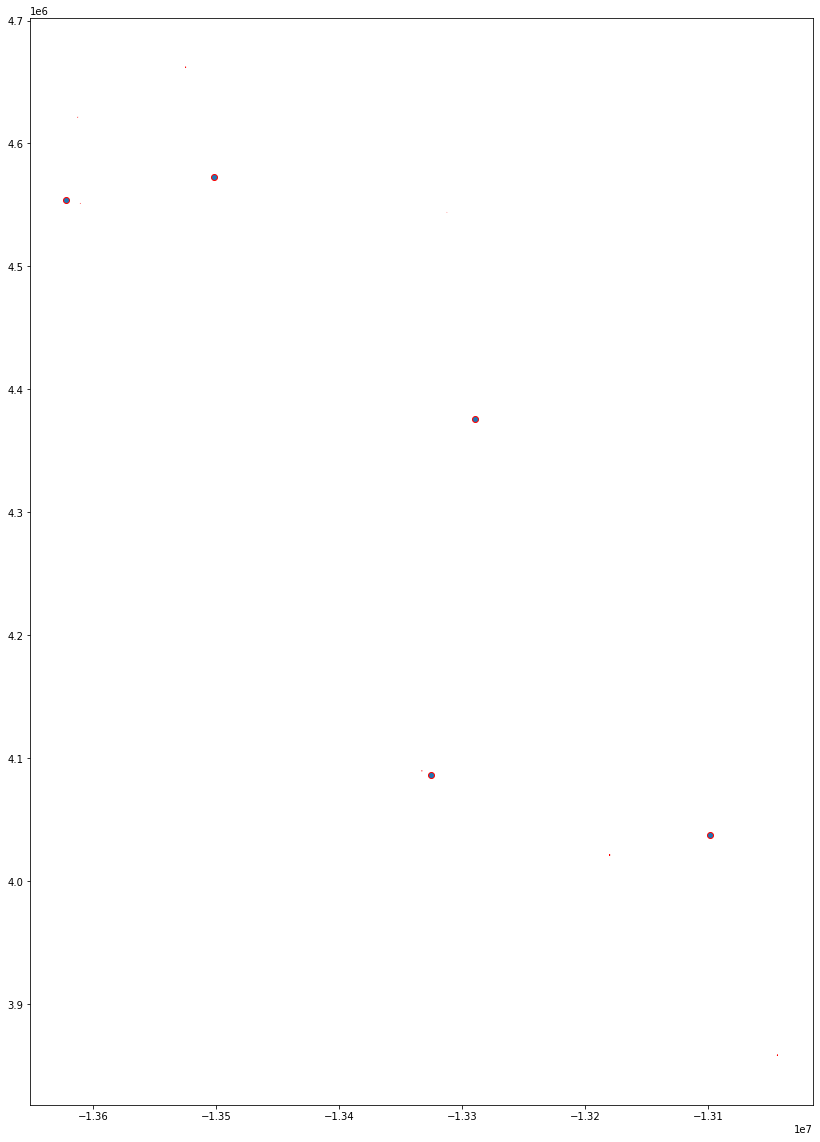

In [211]:
# # Plot the city hall in whole CA state
# import contextily as ctx
# city = city_proj4.to_crs(epsg=3857) # This EPSG-3857 just for ploting
# ax = city.plot(figsize=(20, 20), alpha=1, edgecolor='red')
# ctx.add_basemap(ax)

In [ ]:
eco.crs

In [212]:
# Distance to CBD
eco['min_dist_to_city_hall'] = eco.geometry.apply(min_distance_ppoly, args=(city_proj4,))*0.000621371
output_cbd_distance=eco.loc[:,["site_name","min_dist_to_city_hall"]]
output_cbd_distance.columns=["site_name","min_dist_to_CBD"]
output_cbd_distance.head()

,site_name,min_dist_to_CBD
0,(01) 11th St. Between Howard & Folsom,3.905120
8759,(02) 17th St. between Mission & Valencia,4.596450
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,6.458962
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,6.384093
35036,(10) 8th St. Between Folsom & Harrison,3.621272


In [213]:
output_cbd_distance['min_dist_to_CBD'].describe()

count     51.000000
mean      23.703695
std       36.194577
min        0.538643
25%        4.657355
50%        8.160782
75%       22.129350
max      202.420563
Name: min_dist_to_CBD, dtype: float64

# Aggregate all the extracted data together

In [214]:
gdf2=gdf1[['site_name','latitude','longitude','stratum','geometry']]
gdf3=gpd.GeoDataFrame(gdf2, geometry='geometry', crs={'init': 'epsg:32610'})
gdf3.head()

C:\Users\Md Mintu Miah\anaconda3\envs\geo_env\lib\site-packages\pyproj\crs\crs.py:130: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


,site_name,latitude,longitude,stratum,geometry
0,(01) 11th St. Between Howard & Folsom,37.772475,-122.414678,Path,"POLYGON ((551950.637 4180732.421, 551948.699 4..."
8759,(02) 17th St. between Mission & Valencia,37.763376,-122.420433,Bike Route,"POLYGON ((551450.054 4179719.739, 551448.116 4..."
17518,(07) 7th Ave. Between Lawton & Kirkham - NB,37.759250,-122.463770,Path,"POLYGON ((547635.566 4179239.202, 547633.629 4..."
26277,(07) 7th Ave. Between Lawton & Kirkham - SB,37.761326,-122.464070,Path,"POLYGON ((547607.821 4179469.380, 547605.884 4..."
35036,(10) 8th St. Between Folsom & Harrison,37.774740,-122.409820,Bike Route,"POLYGON ((552376.890 4180986.410, 552374.953 4..."


In [215]:
gdf3.columns

Index(['site_name', 'latitude', 'longitude', 'stratum', 'geometry'], dtype='object')

In [216]:
from functools import reduce
import pandas as pd
# compile the list of dataframes you want to merge
df_all = [gdf3,output_cbd_distance,output_commercial,commercialcc_distance,output_retail,retailcc_distance,output_industrial,industrialcc_distance,
          output_residential,residentialcc_distance,output_grass,grasscc_distance,output_forest,forestcc_distance,output_water,watercc_distance,output_park,parkcc_distance,
         output_school,output_school_distance,output_college,output_college_distance,output_university,output_university_distance,institutionalcc_distance,output_institutional]

In [217]:

names = [
    "output_cbd_distance", "output_commercial", "commercialcc_distance",
    "output_retail", "retailcc_distance", "output_industrial", "industrialcc_distance",
    "output_residential", "residentialcc_distance", "output_grass", "grasscc_distance",
    "output_forest", "forestcc_distance"
   , "output_water", "watercc_distance",
    "output_park", "parkcc_distance", "output_school", "output_school_distance",
    "output_college", "output_college_distance", "output_university", "output_university_distance", "output_institutional", "institutionalcc_distance"
]

for df, name in zip(df_all, names):
    exists = "site_name" in df.columns
    print(f"{name}: {'site_name exists' if exists else 'site_name MISSING'}")

output_cbd_distance: site_name exists
output_commercial: site_name exists
commercialcc_distance: site_name exists
output_retail: site_name exists
retailcc_distance: site_name exists
output_industrial: site_name exists
industrialcc_distance: site_name exists
output_residential: site_name exists
residentialcc_distance: site_name exists
output_grass: site_name exists
grasscc_distance: site_name exists
output_forest: site_name exists
forestcc_distance: site_name exists
output_water: site_name exists
watercc_distance: site_name exists
output_park: site_name exists
parkcc_distance: site_name exists
output_school: site_name exists
output_school_distance: site_name exists
output_college: site_name exists
output_college_distance: site_name exists
output_university: site_name exists
output_university_distance: site_name exists
output_institutional: site_name exists
institutionalcc_distance: site_name exists


In [218]:
#Merge by ID
df_merged_eco = reduce(lambda  left,right: pd.merge(left,right,on=['site_name'],
                                            how='left'), df_all).fillna('0')
df_merged_eco1=df_merged_eco.drop_duplicates(subset=['site_name'],keep='first')
df_merged_eco1.head()

,site_name,latitude,longitude,stratum,geometry,min_dist_to_CBD,Commercial Area,Distance to commercial area,retail Area,Distance to retail area,...,park Area,Distance to Park Center,School,min_dist_to_school,college,min_dist_to_college,University,min_dist_to_university,Distance to institutional area,institutional Area
0,(01) 11th St. Between Howard & Folsom,37.772475,-122.414678,Path,"POLYGON ((551950.637 4180732.421, 551948.699 4...",3.905120,127034.637319,592.975401,221011.423443,752.990225,...,0,1256.117962,1.0,259.828709,0,2580.495134,1.0,882.338822,2865.861548,0
1,(02) 17th St. between Mission & Valencia,37.763376,-122.420433,Bike Route,"POLYGON ((551450.054 4179719.739, 551448.116 4...",4.596450,479150.661847,987.952530,2227691.736582,442.516769,...,0,290.352522,2.0,1196.486431,0,3051.537924,0,3269.215044,1220.391127,24657.917844
2,(07) 7th Ave. Between Lawton & Kirkham - NB,37.759250,-122.463770,Path,"POLYGON ((547635.566 4179239.202, 547633.629 4...",6.458962,0,13590.220075,750469.335982,1583.014568,...,0,577.413620,0,1451.887643,0,7272.202005,0,1911.538609,13783.393148,0
3,(07) 7th Ave. Between Lawton & Kirkham - SB,37.761326,-122.464070,Path,"POLYGON ((547607.821 4179469.380, 547605.884 4...",6.384093,0,13616.088599,761560.271877,846.245869,...,0,1336.122409,1.0,708.958260,0,6793.417997,0,1605.080635,13780.238554,0
4,(10) 8th St. Between Folsom & Harrison,37.774740,-122.409820,Bike Route,"POLYGON ((552376.890 4180986.410, 552374.953 4...",3.621272,127034.637319,485.512663,118906.776603,180.453622,...,0,916.570821,1.0,1137.781709,0,1998.063510,0,1843.634099,3078.642947,0


In [219]:
df_merged_eco2=gpd.GeoDataFrame(df_merged_eco1, geometry='geometry', crs='EPSG:32610') 
df_merged_eco3=df_merged_eco2.to_crs(epsg=4326)

In [220]:
# If you want to export the excel
pd.DataFrame.to_csv(df_merged_eco3, 'Eco_CA_data_circular_0.25_mile_buffer.csv', sep=',', na_rep='0', index=False)

# Import KeplerGL Dynamic Map

In [328]:
df_merged_eco1.isnull().values.any()

False

In [329]:
#!conda install -c conda-forge keplergl

In [330]:
#!pip install keplergl==0.1.1
#!jupyter nbextension install --py --sys-prefix keplergl
#!jupyter nbextension enable --py --sys-prefix keplergl


In [331]:
#!jupyter labextension install @jupyter-widgets/jupyterlab-manager keplergl-jupyter

In [332]:
# Load an empty map
from keplergl import KeplerGl
map_1 = KeplerGl()
map_1

User Guide: https://github.com/keplergl/kepler.gl/blob/master/docs/keplergl-jupyter/user-guide.md


KeplerGl()

In [333]:
#!conda install -c conda-forge nodejs
#!jupyter labextension install @jupyter-widgets/jupyterlab-manager

In [334]:
# Load a map with data and config and height
from keplergl import KeplerGl
data=pd.read_csv("Eco_CA_data_circular_0.5_mile_buffer.csv")
#data=data.fillna(0)
map_2 =KeplerGl(height=300, data={"data_1":data})
map_2

User Guide: https://github.com/keplergl/kepler.gl/blob/master/docs/keplergl-jupyter/user-guide.md


KeplerGl(data={'data_1':             id        lat        long                 user_type  \
0    100000572  37…

In [335]:
# save as htm file
map_2.save_to_html(file_name="CA_keplergl_circular_0.5_mile_buffer.html")

Map saved to CA_keplergl_circular_0.5_mile_buffer.html!


In [336]:
end = time.time()
print("Total Run Time:", end - start)

Total Run Time: 772.2033498287201
